In [2]:
# ============================================================
# SKEMPI benchmarking with TRUE ΔH labels from binding_affinity_deltaH.txt
# - ESM OFF
# - Computes metrics: R2, PearsonR, Spearman, MAE, RMSE
# - No file writes
# ============================================================

import os, re, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---------------------------
# PATHS (same as your model)
# ---------------------------
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TARGETS    = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"
SASA_PATH  = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/all_pdb_sasa.txt"

MODEL_PATH = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model.joblib"
SKEMPI_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/benchmarking/skempi2/SKEMPI"

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]  # 94

# ---------------------------
# Helpers
# ---------------------------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols:
            return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)

    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")

    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try:
                return to_1d_numpy(v)
            except Exception:
                continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")

    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    if arr.ndim > 1:
        arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}")
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

def load_sasa_table(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]

    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")

    cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id) if "pdb_id" in df.columns else None
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)

    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")

    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"].mean(numeric_only=True).to_frame()
    return df.sort_index()

def load_targets_deltaH(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    if "PDB_ID" in df.columns and "pdb_id" not in df.columns:
        df = df.rename(columns={"PDB_ID": "pdb_id"})
    for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
        if col in df.columns and "delta_H" not in df.columns:
            df = df.rename(columns={col: "delta_H"})
    if "pdb_id" not in df.columns or "delta_H" not in df.columns:
        raise ValueError(f"Targets must contain pdb_id and delta_H. Got cols: {list(df.columns)}")
    df["JOIN_ID"] = df["pdb_id"].apply(normalize_pdb_id)
    df["delta_H"] = pd.to_numeric(df["delta_H"], errors="coerce")
    return df.set_index("JOIN_ID")[["delta_H"]].sort_index()

def metrics_block(y, p):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    mse = mean_squared_error(y, p)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y, p))
    r2 = float(r2_score(y, p))
    R = float(pearsonr(y, p)[0]) if len(y) >= 2 else float("nan")
    rho = float(spearmanr(y, p)[0]) if len(y) >= 2 else float("nan")
    return dict(R2=r2, PearsonR=R, Spearman=rho, MAE=mae, RMSE=rmse)

# ---------------------------
# 1) IDs from SKEMPI dir
# ---------------------------
pdb_files = sorted(glob.glob(os.path.join(SKEMPI_DIR, "*.pdb")))
raw_ids = [os.path.splitext(os.path.basename(p))[0].strip() for p in pdb_files]
skempi_ids = [normalize_pdb_id(x) for x in raw_ids]
skempi_ids = [i for i in skempi_ids if re.fullmatch(r"[0-9a-z]{4}", i)]

print(f"[SKEMPI] Found {len(pdb_files)} .pdb files; parsed {len(skempi_ids)} valid IDs.")
print("[SKEMPI] Example IDs:", skempi_ids[:10])

# ---------------------------
# 2) Filter by TXT allowlist
# ---------------------------
allowed = load_id_list(PDB_TXT)
ids_txt = sorted(set([i for i in skempi_ids if i in allowed]))
print(f"[TXT] In allowlist: {len(ids_txt)} / {len(set(skempi_ids))}")
if not ids_txt:
    raise RuntimeError("No SKEMPI IDs are in the model TXT allowlist.")

# ---------------------------
# 3) Load ΔH targets; keep only labeled SKEMPI IDs
# ---------------------------
df_y = load_targets_deltaH(TARGETS)  # index=JOIN_ID, col=delta_H
ids_lbl = [i for i in ids_txt if i in df_y.index and pd.notna(df_y.loc[i, "delta_H"])]
print(f"[TARGETS] Labeled (ΔH present): {len(ids_lbl)} / {len(ids_txt)}")

if not ids_lbl:
    raise RuntimeError("None of the SKEMPI allowlisted IDs have ΔH labels in TARGETS.")

# ---------------------------
# 4) Load model bundle
# ---------------------------
bundle = joblib.load(MODEL_PATH)
rf   = bundle["rf"]
et   = bundle["et"]
hgb  = bundle["hgb"]
meta = bundle["meta"]

pt_dim = bundle.get("pt_dim", None)
use_sasa = bool(bundle.get("use_sasa", False))
use_esm  = bool(bundle.get("use_esm", False))
extra_scalar_cols = bundle.get("extra_scalar_cols", []) or []
bf_cols = bundle.get("bf_cols", []) or []

print(f"[MODEL] PT dim={pt_dim} | use_sasa={use_sasa} | use_esm={use_esm} | extra_scalars={extra_scalar_cols} | bf_cols={bf_cols}")
if use_esm:
    raise RuntimeError("Your saved model says ESM was used, but your setup is ESM OFF. Use matching model bundle.")

# ---------------------------
# 5) Load CSV A/B and filter IDs present there
# ---------------------------
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

ids_csv = [i for i in ids_lbl if (i in df_a.index and i in df_b.index)]
print(f"[CSV] Present in BOTH A and B: {len(ids_csv)} / {len(ids_lbl)}")
if not ids_csv:
    raise RuntimeError("No labeled SKEMPI IDs are present in both CSV_A and CSV_B.")

# ---------------------------
# 6) Load PT vectors and keep correct length
# ---------------------------
PT_list, ids_pt = [], []
for pid in ids_csv:
    v = load_pt_vector(FEAT_DIR, pid)
    if pt_dim is not None and len(v) != pt_dim:
        continue
    PT_list.append(v)
    ids_pt.append(pid)

print(f"[PT] Loaded PT: {len(ids_pt)} / {len(ids_csv)}")
if not ids_pt:
    raise RuntimeError("No PT vectors loaded after filtering.")

PT = np.vstack(PT_list).astype(np.float64)

# ---------------------------
# 7) Scalars (SASA + complex_count etc.)
#    - SASA joined if available
#    - complex_count not available from SKEMPI PDBs; set to 1.0 (recommended)
# ---------------------------
df_scalar = pd.DataFrame(index=ids_pt)

if use_sasa:
    df_sasa = load_sasa_table(SASA_PATH)  # has total_sasa_A2
    df_scalar = df_scalar.join(df_sasa, how="left")
    df_scalar["total_sasa_kA2"] = df_scalar["total_sasa_A2"] / 1000.0
    print("[SASA] Missing total_sasa_A2:", int(df_scalar["total_sasa_A2"].isna().sum()), "/", len(df_scalar))

# Provide complex_count as 1.0 for single-PDB benchmarks (avoids imputation drift)
if "complex_count" in extra_scalar_cols and "complex_count" not in df_scalar.columns:
    df_scalar["complex_count"] = 1.0

# Ensure expected scalar cols exist (NaN ok; pipeline imputes)
for c in extra_scalar_cols:
    if c not in df_scalar.columns:
        df_scalar[c] = np.nan
for c in bf_cols:
    if c not in df_scalar.columns:
        df_scalar[c] = np.nan

# ---------------------------
# 8) Build X (ESM OFF)
# ---------------------------
A = df_a.loc[ids_pt, FEATURE_COLS].to_numpy(dtype=np.float64)
B = df_b.loc[ids_pt, FEATURE_COLS].to_numpy(dtype=np.float64)

SUM   = A + B
DIFF  = A - B
ADIFF = np.abs(DIFF)
PROD  = A * B
COS   = ((A * B).sum(axis=1) /
         (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-8)).reshape(-1, 1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A, B, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT]
if extra_scalar_cols:
    parts.append(df_scalar.loc[ids_pt, extra_scalar_cols].to_numpy(dtype=np.float64))
if bf_cols:
    parts.append(df_scalar.loc[ids_pt, bf_cols].to_numpy(dtype=np.float64))

X = np.hstack(parts).astype(np.float64)
y = df_y.loc[ids_pt, "delta_H"].to_numpy(dtype=np.float64)

print("[X,y] Shapes:", X.shape, y.shape)

# ---------------------------
# 9) Predict
# ---------------------------
p_rf  = rf.predict(X)
p_et  = et.predict(X)
p_hgb = hgb.predict(X)

p_bl3 = (p_rf + p_et + p_hgb) / 3.0

meta_X = np.column_stack([
    p_rf, p_et, p_hgb,
    (p_rf + p_et + p_hgb) / 3.0,
    p_rf - p_et,
    p_rf - p_hgb,
    p_et - p_hgb
])
p_stack = meta.predict(meta_X)

# ---------------------------
# 10) Metrics report
# ---------------------------
rows = []
for name, p in [("RF", p_rf), ("ET", p_et), ("HGB", p_hgb), ("Blend3", p_bl3), ("Stack", p_stack)]:
    m = metrics_block(y, p)
    rows.append({"model": name, **m})

df_metrics = pd.DataFrame(rows).set_index("model")
print("\n=== SKEMPI BENCHMARK METRICS (ΔH) ===")
print(df_metrics)

# ---------------------------
# 11) Per-sample table (for inspection)
# ---------------------------
df_eval = pd.DataFrame({
    "JOIN_ID": ids_pt,
    "delta_H": y,
    "pred_rf": p_rf,
    "pred_et": p_et,
    "pred_hgb": p_hgb,
    "pred_blend3": p_bl3,
    "pred_stack": p_stack,
    "has_sasa": (~df_scalar.get("total_sasa_A2", pd.Series(index=ids_pt, data=np.nan)).isna()).astype(int).values
}).set_index("JOIN_ID").sort_index()

print("\n[Eval head]")
print(df_eval.head(10))

print("\n[DONE] Evaluated on", len(df_eval), "SKEMPI IDs with ΔH labels.")

# df_metrics and df_eval are now available in memory


[SKEMPI] Found 345 .pdb files; parsed 345 valid IDs.
[SKEMPI] Example IDs: ['1a22', '1a4y', '1acb', '1ahw', '1ak4', '1ao7', '1b2s', '1b2u', '1b3s', '1b41']
[TXT] In allowlist: 140 / 345
[TARGETS] Labeled (ΔH present): 140 / 140
[MODEL] PT dim=1440 | use_sasa=True | use_esm=False | extra_scalars=['complex_count', 'total_sasa_kA2'] | bf_cols=[]
[CSV] Present in BOTH A and B: 140 / 140
[PT] Loaded PT: 140 / 140
[SASA] Missing total_sasa_A2: 25 / 140
[X,y] Shapes: (140, 2101) (140,)

=== SKEMPI BENCHMARK METRICS (ΔH) ===
              R2  PearsonR  Spearman       MAE       RMSE
model                                                    
RF      0.807942  0.938435  0.928067  4.861630   6.925817
ET      0.918832  0.964598  0.952908  2.541744   4.502428
HGB     0.378556  0.805494  0.820857  9.114601  12.458207
Blend3  0.779251  0.941723  0.935554  5.101840   7.425118
Stack   0.707948  0.917434  0.923084  6.272253   8.540517

[Eval head]
         delta_H    pred_rf    pred_et   pred_hgb  pred_bl

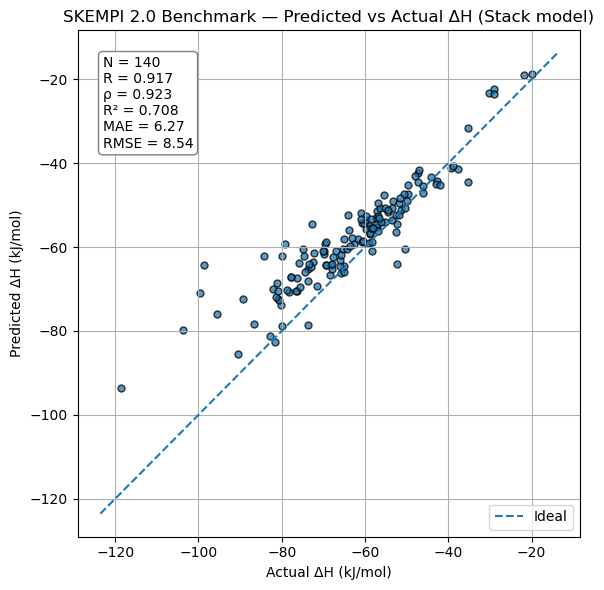

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("SKEMPI 2.0 Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
